### Exploratory Data Analysis for Research Question 4 and 5
- Q4: Is formal saving associated with greater financial resilience in Thailand, and has this relationship changed between 2021 and 2024? 
 

- Q5: Is greater financial inclusion associated with greater financial resilience in Thailand?

Financial inclusion -> Access ->  Ownership -> Usage->Saving / Borrowing -> Financial health

In [19]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

sns.set(style="whitegrid", context="notebook") 
plt.rcParams['figure.dpi'] = 100 
pd.set_option('display.max_columns', 12)
pd.set_option('display.max_rows', 12)

df4 = pd.read_csv("data_cleaned_2024.csv")

In [6]:
df4.columns.tolist()

['merchantpay_dig',
 'account_withdrawal_frequency',
 'no_account_insufficient_funds',
 'emergency_fund_source',
 'female',
 'received_public_pension',
 'respondent_id',
 'wages_mobile',
 'survey_weight',
 'account_money_deposit_frequency',
 'mobile_money_activity',
 'received_wages',
 'saved_bank',
 'saved_mobile_money',
 'received_transfers',
 'recieved_wages',
 'made_utility_payment',
 'received_acc_balance_info',
 'store_money_account',
 'agriculture_payment_account',
 'ever_had_mobile_money_account',
 'mobile_money_usage',
 'utility_payment',
 'economycode',
 'no_mobile_account_lack_documentation',
 'any_digital_payment',
 'received_agriculture_payment',
 'no_account_lack_of_trust',
 'no_account_distance',
 'credit_card_ownership',
 'education_level',
 'survey_year',
 'borrowed_from_family_friends',
 'no_account_too_expensive',
 'agricultural_payment_mobile',
 'no_account_documentation',
 'borrowed_from_formal_bank',
 'utility_payment_cash',
 'mobile_money_send_recieve',
 'sent_do

In [7]:
df4["account_money_deposit_frequency"] = df4["account_money_deposit_frequency"].astype("Int64") 

In [9]:
print(df4["account_money_deposit_frequency"].value_counts(dropna=False))

account_money_deposit_frequency
1       979
2       637
<NA>    163
3       145
4        64
6        22
5         7
Name: count, dtype: Int64


In [10]:
account_usage_labels = {
    1: "Weekly deposit",
    2: "Monthly deposit",
    3: "Less than monthly deposit",
    4: "Never deposited",
    5: "Don't know",
    6: "Refused"}
# account_usage is only asked of account owners, so non-owners are NA 
df4["account_usage_label"] = (df4["account_money_deposit_frequency"].map(account_usage_labels).fillna("Not applicable (no account)"))
print(df4["account_usage_label"].value_counts(dropna=False))

account_usage_label
Weekly deposit                 979
Monthly deposit                637
Not applicable (no account)    163
Less than monthly deposit      145
Never deposited                 64
Refused                         22
Don't know                       7
Name: count, dtype: int64


### Financial Health Indicator

In [6]:
df_health = df4[df4["financial_health_indicator"].isin([1, 2, 3, 4, 5, 6, 7, 8])].copy()

In [21]:
print(df4["financial_health_indicator"].value_counts(dropna=False))

financial_health_indicator
NaN    458
4.0    444
3.0    369
1.0    344
2.0    200
5.0    113
6.0     36
7.0     33
8.0     20
Name: count, dtype: int64


In [11]:
financial_health_labels = {
    1: "Not enough money for old age",
    2: "Not enough money for business",
    3: "Not enough money for medical costs after a serious illness or accident",
    4: "Not enough money for monthly expenses",
    5: "Not enough money for school or education fees",
    6: "Not enough money for another reason",
    7: "Don't know",
    8: "Refused",}
# Missing values represent respondents without a recorded answer.
df4["financial_health_labels"] = (df4["financial_health_indicator"].map(financial_health_labels).fillna("Missing"))
print(df4["financial_health_labels"].value_counts(dropna=False))

financial_health_labels
Missing                                                                   458
Not enough money for monthly expenses                                     444
Not enough money for medical costs after a serious illness or accident    369
Not enough money for old age                                              344
Not enough money for business                                             200
Not enough money for school or education fees                             113
Not enough money for another reason                                        36
Don't know                                                                 33
Refused                                                                    20
Name: count, dtype: int64


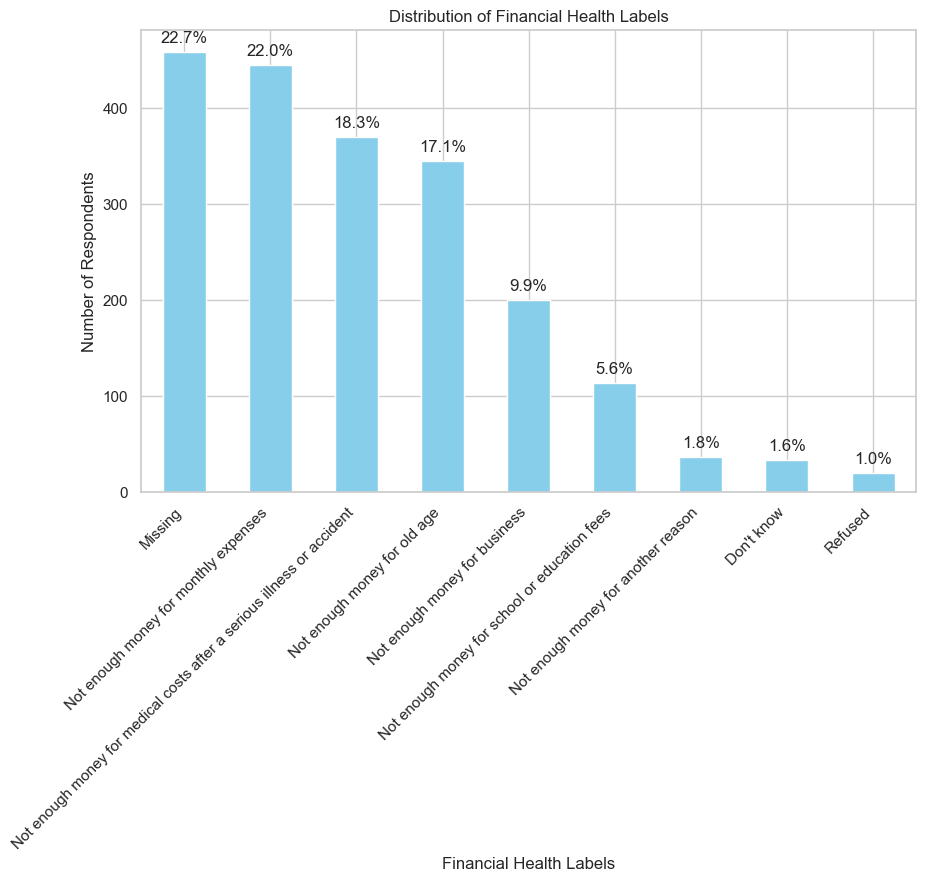

In [12]:
import matplotlib.pyplot as plt 

health_counts =(
    df4["financial_health_labels"].value_counts()
)

plt.figure(figsize=(10, 6))
health_counts.plot(kind="bar" , color='skyblue' )
total = health_counts.sum()
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height()/total:.1%}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 10), textcoords='offset points') # type: ignore
plt.xlabel("Financial Health Labels")
plt.ylabel("Number of Respondents")
plt.title("Distribution of Financial Health Labels")
plt.xticks(rotation=45, ha='right')
plt.show()

### Gender x Financial Health 

In [10]:
gender_health = pd.crosstab(df4["gender"],df4["financial_health_labels"],normalize="index") * 100
print(gender_health)

financial_health_labels  Don't know    Missing  \
gender                                           
Female                     1.816530  18.982743   
Male                       1.419214  27.183406   

financial_health_labels  Not enough money for another reason  \
gender                                                         
Female                                              1.725704   
Male                                                1.855895   

financial_health_labels  Not enough money for business  \
gender                                                   
Female                                       10.172570   
Male                                          9.606987   

financial_health_labels  Not enough money for medical costs after a serious illness or accident  \
gender                                                                                            
Female                                                           17.801998                        
Male        

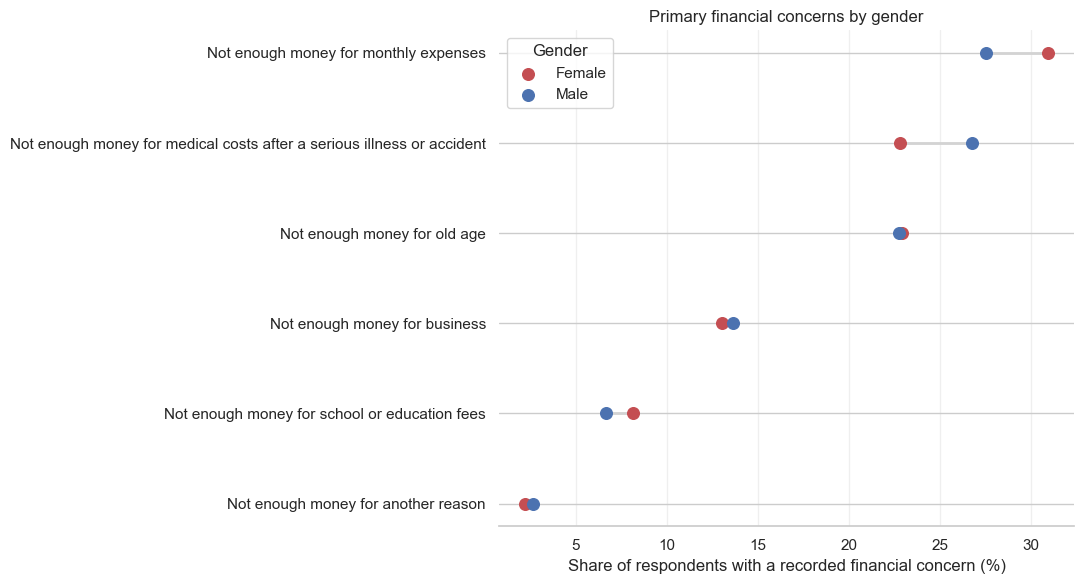

In [11]:
concern_order = [
    "Not enough money for monthly expenses",
    "Not enough money for medical costs after a serious illness or accident",
    "Not enough money for old age",
    "Not enough money for business",
    "Not enough money for school or education fees",
    "Not enough money for another reason",]

valid_concerns = df4[df4["financial_health_labels"].isin(concern_order)]
gender_concerns = (pd.crosstab(
    valid_concerns["financial_health_labels"],
    valid_concerns["gender"],normalize="columns",).mul(100).reindex(concern_order))

fig, ax = plt.subplots(figsize=(11, 6))
y_positions = np.arange(len(gender_concerns))

for position, (_, row) in enumerate(gender_concerns.iterrows()):
    ax.plot(
        [row["Female"], row["Male"]],
        [position, position],
        color="lightgray",
        linewidth=2,
        zorder=1,)

ax.scatter(gender_concerns["Female"], y_positions, color="#c44e52", s=70, label="Female", zorder=2)
ax.scatter(gender_concerns["Male"], y_positions, color="#4c72b0", s=70, label="Male", zorder=2)

ax.set_yticks(y_positions, concern_order)
ax.invert_yaxis()
ax.set_xlabel("Share of respondents with a recorded financial concern (%)")
ax.set_title("Primary financial concerns by gender")
ax.legend(title="Gender")
ax.grid(axis="x", alpha=0.3)
ax.spines[["top", "right", "left"]].set_visible(False)
plt.tight_layout()
plt.show()

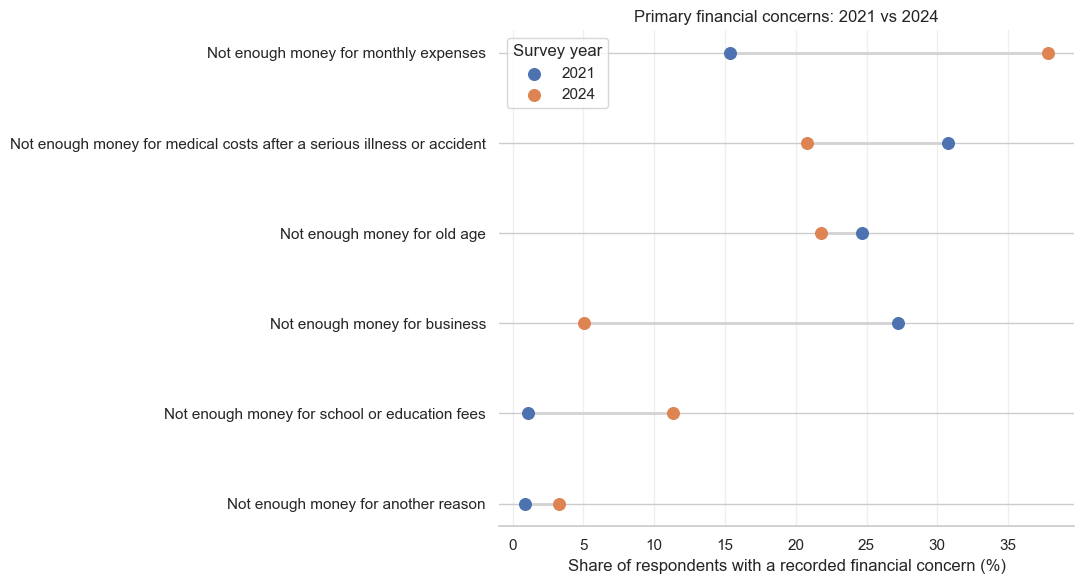

In [12]:
year_order = [2021, 2024]
valid_year_concerns = valid_concerns[valid_concerns["survey_year"].isin(year_order)]
year_concerns = (pd.crosstab(
        valid_year_concerns["financial_health_labels"],
        valid_year_concerns["survey_year"],
        normalize="columns",).mul(100).reindex(concern_order).reindex(columns=year_order))

fig, ax = plt.subplots(figsize=(11, 6))
y_positions = np.arange(len(year_concerns))

for position, (_, row) in enumerate(year_concerns.iterrows()):
    ax.plot(
        [row[2021], row[2024]],
        [position, position],
        color="lightgray",
        linewidth=2,
        zorder=1,
    )

ax.scatter(year_concerns[2021], y_positions, color="#4c72b0", s=70, label="2021", zorder=2)
ax.scatter(year_concerns[2024], y_positions, color="#dd8452", s=70, label="2024", zorder=2)

ax.set_yticks(y_positions, concern_order)
ax.invert_yaxis()
ax.set_xlabel("Share of respondents with a recorded financial concern (%)")
ax.set_title("Primary financial concerns: 2021 vs 2024")
ax.legend(title="Survey year")
ax.grid(axis="x", alpha=0.3)
ax.spines[["top", "right", "left"]].set_visible(False)
plt.tight_layout()
plt.show()

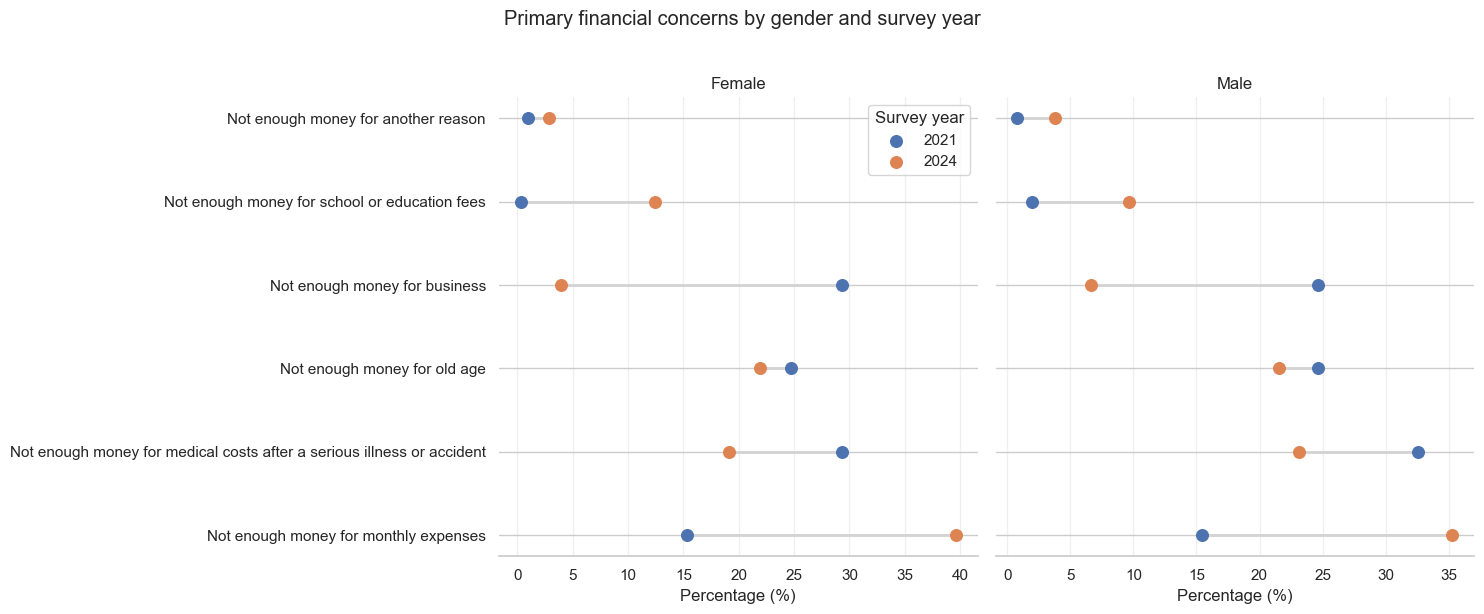

In [13]:
gender_year_concerns = (
    valid_year_concerns.groupby(
        ["gender", "financial_health_labels", "survey_year"]
    )
    .size()
    .groupby(level=[0, 2])
    .transform(lambda counts: counts / counts.sum() * 100)
    .unstack("survey_year")
    .reindex(
        pd.MultiIndex.from_product(
            [["Female", "Male"], concern_order],
            names=["gender", "financial_health_labels"],
            )
        )
    .reindex(columns=year_order)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
y_positions = np.arange(len(concern_order))
year_colors = {2021: "#4c72b0", 2024: "#dd8452"}

for ax, gender in zip(axes, ["Female", "Male"]):
    concern_values = gender_year_concerns.loc[gender]

    for position, (_, row) in enumerate(concern_values.iterrows()):
        ax.plot(
            [row[2021], row[2024]],
            [position, position],
            color="lightgray",
            linewidth=2,
            zorder=1,
        )

    for year in year_order:
        ax.scatter(
            concern_values[year],
            y_positions,
            color=year_colors[year],
            s=70,
            label=str(year),
            zorder=2,
        )

    ax.set_title(gender)
    ax.set_xlabel("Percentage (%)")
    ax.set_yticks(y_positions, concern_order)
    ax.invert_yaxis()
    ax.grid(axis="x", alpha=0.3)
    ax.spines[["top", "right", "left"]].set_visible(False)

axes[0].legend(title="Survey year")
fig.suptitle("Primary financial concerns by gender and survey year", y=1.02)
plt.tight_layout()
plt.show()

### Chi-Square Test for Gender and Health Concerns

In [13]:
df4["financial_health_indicator"].value_counts(dropna=False)

financial_health_indicator
NaN    458
4.0    444
3.0    369
1.0    344
2.0    200
5.0    113
6.0     36
7.0     33
8.0     20
Name: count, dtype: int64

In [ ]:
from scipy.stats import chi2_contingency

alpha = 0.05

# concern test: omit missing, Don't know (7), and Refused (8).
concern_data = df4[df4["financial_health_indicator"].isin([1, 2, 3, 4, 5, 6])].dropna(subset=["gender"])
concern_table = pd.crosstab(concern_data["gender"], concern_data["financial_health_indicator"])
chi2, p, dof, expected = chi2_contingency(concern_table)
concern_decision = "Reject H0" if p < alpha else "Fail to reject H0"  # type: ignore

print("Test 1: Gender and primary financial concern")
print("H0: Gender and primary financial concern are independent.")
print("Ha: Gender and primary financial concern are associated.")
print(f"Chi2({dof}) = {chi2:.3f}, p-value = {p:.4f}")
print(f"Decision at alpha = {alpha}: {concern_decision}.")
if p < alpha: # type: ignore
    print("Conclusion: There is evidence that primary financial concern differs by gender.")
else:
    print("Conclusion: There is insufficient evidence that primary financial concern differs by gender.")

# Test nonresponse separately; decided not to treat missingness as a financial concern.
missingness_table = pd.crosstab(df4.dropna(subset=["gender"])["gender"],
                                df4.dropna(subset=["gender"])["financial_health_indicator"].isna().map({False: "Recorded", True: "Missing"}),)
missing_chi2, missing_p, missing_dof, missing_expected = chi2_contingency(missingness_table)
missing_decision = "Reject H0" if missing_p < alpha else "Fail to reject H0" # type: ignore

print("\nTest 2: Gender and financial-health nonresponse")
print("H0: Financial-health response missingness is independent of gender.")
print("Ha: Financial-health response missingness is associated with gender.")
print(f"Chi2({missing_dof}) = {missing_chi2:.3f}, p-value = {missing_p:.4g}")
print(f"Decision at alpha = {alpha}: {missing_decision}.")
if missing_p < alpha: # type: ignore
    print("Conclusion: Financial-health nonresponse differs by gender.")
else:
    print("Conclusion: There is insufficient evidence that financial-health nonresponse differs by gender.")

Test 1: Gender and primary financial concern
H0: Gender and primary financial concern are independent.
Ha: Gender and primary financial concern are associated.
Chi2(5) = 5.283, p-value = 0.3824
Decision at alpha = 0.05: Fail to reject H0.
Conclusion: There is insufficient evidence that primary financial concern differs by gender.

Test 2: Gender and financial-health nonresponse
H0: Financial-health response missingness is independent of gender.
Ha: Financial-health response missingness is associated with gender.
Chi2(1) = 18.695, p-value = 1.534e-05
Decision at alpha = 0.05: Reject H0.
Conclusion: Financial-health nonresponse differs by gender.


In [ ]:
yearly_chi_square_results = []

for year in year_order:
    year_data = concern_data[concern_data["survey_year"] == year]
    year_table = pd.crosstab(year_data["gender"], year_data["financial_health_indicator"])
    
    year_chi2, year_p, year_dof, year_expected = chi2_contingency(year_table)
    year_decision = "Reject H0" if year_p < alpha else "Fail to reject H0"  # type: ignore

    yearly_chi_square_results.append(
        {
            "Survey year": year,
            "Chi-square": round(year_chi2, 3), # type: ignore
            "Degrees of freedom": year_dof,
            "p-value": round(year_p, 4), # type: ignore
            "Decision": year_decision,
        }
    )

    print(f"{year}: Gender and primary financial concern")
    print("H0: Gender and primary financial concern are independent.")
    print("Ha: Gender and primary financial concern are associated.")
    print(f"Chi2({year_dof}) = {year_chi2:.3f}, p-value = {year_p:.4f}")
    print(f"Decision at alpha = {alpha}: {year_decision}.")
    print()

yearly_chi_square_results = pd.DataFrame(yearly_chi_square_results)
display(yearly_chi_square_results)

2021: Gender and primary financial concern
H0: Gender and primary financial concern are independent.
Ha: Gender and primary financial concern are associated.
Chi2(5) = 5.200, p-value = 0.3920
Decision at alpha = 0.05: Fail to reject H0.

2024: Gender and primary financial concern
H0: Gender and primary financial concern are independent.
Ha: Gender and primary financial concern are associated.
Chi2(5) = 8.192, p-value = 0.1459
Decision at alpha = 0.05: Fail to reject H0.



,Survey year,Chi-square,Degrees of freedom,p-value,Decision
0,2021,5.200,5,0.3920,Fail to reject H0
1,2024,8.192,5,0.1459,Fail to reject H0


### Logistic Regression: Gender, Year, and Financial Concern

To keep the three-way analysis interpretable, each financial concern is modeled as a binary outcome. The Gender × Year interaction tests whether the gender difference in a specific concern changed between 2021 and 2024.

In [ ]:
import statsmodels.formula.api as smf

model_columns = [
    "financial_health_indicator",
    "gender",
    "survey_year",
    "age",
    "education_level",
    "income_quintile",
    "employment_status",
    ]
model_data = df4.loc[df4["financial_health_indicator"].isin([1, 2, 3, 4, 5, 6]), model_columns].dropna()

# Use the descriptive gender field, with Male as the explicit reference group.
model_data = model_data.copy()
model_data["monthly_expense_concern"] = (model_data["financial_health_indicator"] == 4).astype(int)

gender_term = "C(gender, Treatment(reference='Male'))"
interaction_term = f"{gender_term}[T.Female]:C(survey_year)[T.2024]"
model_formula = (
    "monthly_expense_concern ~ "
    f"{gender_term} * C(survey_year) + age + "
    "C(education_level) + C(income_quintile) + C(employment_status)"
)
monthly_expense_model = smf.logit(model_formula, data=model_data).fit(disp=False)

interaction_odds_ratio = np.exp(monthly_expense_model.params[interaction_term])
interaction_ci = np.exp(monthly_expense_model.conf_int().loc[interaction_term])
interaction_p_value = monthly_expense_model.pvalues[interaction_term]

print("Monthly-expense concern model")
print("H0: The gender difference did not change between 2021 and 2024.")
print("Ha: The gender difference changed between 2021 and 2024.")
print(f"Gender x Year odds ratio: {interaction_odds_ratio:.2f}")
print(f"95% CI: [{interaction_ci.iloc[0]:.2f}, {interaction_ci.iloc[1]:.2f}]")
print(f"p-value: {interaction_p_value:.4f}")
print("Decision:", "Reject H0" if interaction_p_value < alpha else "Fail to reject H0")

# Repeat the same Gender x Year interaction test for every substantive concern.
interaction_results = []
for concern_code, concern_label in financial_health_labels.items():
    if concern_code not in range(1, 7):
        continue

    concern_model_data = model_data.copy()
    concern_model_data["specific_concern"] = (
        concern_model_data["financial_health_indicator"] == concern_code
    ).astype(int)
    concern_formula = model_formula.replace("monthly_expense_concern", "specific_concern")
    concern_model = smf.logit(concern_formula, data=concern_model_data).fit(disp=False)

    coefficient = concern_model.params[interaction_term]
    confidence_interval = concern_model.conf_int().loc[interaction_term]
    p_value = concern_model.pvalues[interaction_term]
    interaction_results.append(
        {
            "Financial concern": concern_label,
            "Interaction odds ratio": np.exp(coefficient),
            "95% CI lower": np.exp(confidence_interval.iloc[0]),
            "95% CI upper": np.exp(confidence_interval.iloc[1]),
            "p-value": p_value,
            "Decision": "Reject H0" if p_value < alpha else "Fail to reject H0",
        }
    )

interaction_results = pd.DataFrame(interaction_results)
interaction_results[["Interaction odds ratio", "95% CI lower", "95% CI upper", "p-value"]] = (
    interaction_results[["Interaction odds ratio", "95% CI lower", "95% CI upper", "p-value"]].round(3)
)
display(interaction_results)

Monthly-expense concern model
H0: The gender difference did not change between 2021 and 2024.
Ha: The gender difference changed between 2021 and 2024.
Gender x Year odds ratio: 1.25
95% CI: [0.73, 2.15]
p-value: 0.4103
Decision: Fail to reject H0


,Financial concern,Interaction odds ratio,95% CI lower,95% CI upper,p-value,Decision
0,Not enough money for old age,0.993,0.597,1.650,0.978,Fail to reject H0
1,Not enough money for business,0.457,0.225,0.926,0.030,Reject H0
2,Not enough money for medical costs after a ser...,0.856,0.527,1.389,0.529,Fail to reject H0
3,Not enough money for monthly expenses,1.254,0.732,2.149,0.410,Fail to reject H0
4,Not enough money for school or education fees,9.558,1.059,86.289,0.044,Reject H0
5,Not enough money for another reason,0.578,0.082,4.089,0.583,Fail to reject H0


### Key results

Overall conclusion
The strongest evidence is that:

Concern about monthly expenses increased substantially in 2024, especially relative to 2021.
There is no statistically significant gender difference in monthly-expense concern after adjustment.
There is no evidence that the monthly-expense gender difference changed between 2021 and 2024.
The gender-time relationship appears to differ for business concerns and education-fee concerns, but these findings should be treated cautiously because six interaction tests were conducted without a multiple-testing adjustment.
The missing-response analysis found that nonresponse differed by gender, so missing data may introduce bias and should be reported as a limitation.

In [ ]:
monthly_expense_results = pd.DataFrame(
    {
        "Term": monthly_expense_model.params.index,
        "Coefficient": monthly_expense_model.params.values,
        "Odds ratio": np.exp(monthly_expense_model.params.values),
        "95% CI lower": np.exp(monthly_expense_model.conf_int().iloc[:, 0].values),
        "95% CI upper": np.exp(monthly_expense_model.conf_int().iloc[:, 1].values),
        "p-value": monthly_expense_model.pvalues.values,
    }
)

monthly_expense_results[["Coefficient", "Odds ratio", 
                        "95% CI lower", "95% CI upper", "p-value"]] = monthly_expense_results[["Coefficient", "Odds ratio", "95% CI lower",
                                                                                            "95% CI upper", "p-value"]].round(3)

print("Adjusted logistic regression: monthly-expense concern")
print(f"Observations: {int(monthly_expense_model.nobs)}")
print(f"McFadden pseudo R-squared: {monthly_expense_model.prsquared:.3f}")
print("Reference groups: male respondents, survey year 2021, and the first category in each control variable.")
display(monthly_expense_results)

Adjusted logistic regression: monthly-expense concern
Observations: 1498
McFadden pseudo R-squared: 0.063
Reference groups: male respondents, survey year 2021, and the first category in each control variable.


,Term,Coefficient,Odds ratio,95% CI lower,95% CI upper,p-value
0,Intercept,-0.973,0.378,0.213,0.672,0.001
1,"C(gender, Treatment(reference='Male'))[T.Female]",-0.023,0.977,0.613,1.558,0.923
2,C(survey_year)[T.2024],1.071,2.918,1.911,4.458,0.000
3,C(education_level)[T.2.0],-0.207,0.813,0.608,1.088,0.164
4,C(education_level)[T.3.0],-0.462,0.630,0.427,0.929,0.020
5,C(income_quintile)[T.Q2],0.103,1.109,0.763,1.611,0.588
6,C(income_quintile)[T.Q3],0.024,1.024,0.698,1.505,0.902
7,C(income_quintile)[T.Q4],0.144,1.155,0.792,1.684,0.453
8,C(income_quintile)[T.Q5 Highest],-0.312,0.732,0.496,1.080,0.116
9,C(employment_status)[T.2.0],0.045,1.046,0.789,1.386,0.756


## Interpretation of Logistic Regression Results 
OD: Odds Ratio is a measure of association between an exposure and an outcome. It represents the odds that an outcome will occur given a particular exposure, compared to the odds of the outcome occurring without that exposure. 
Ranges:
- OR > 1: Higher odds(means higher likelihood) of the outcome occurring with the exposure.
- OR < 1: Lower odds(means lower likelihood) of the outcome occurring with the exposure.
- OR = 1: No association between the exposure and the outcome.

Odds are calculated as:

$Odds = \frac{p}{1-p}$

Where:
- $p$ = probability of the outcome occurring
- $1-p$ = probability of the outcome not occurring

Interpretation:
- OR > 1: higher odds of the outcome when the exposure is present
- OR < 1: lower odds of the outcome when the exposure is present
- OR = 1: no association

Example:
- Initial probability: $p = 0.20$
- Initial odds: $0.20 / 0.80 = 0.25$

- New probability: $p = 0.40$
- New odds: $0.40 / 0.60 \approx 0.67$

- Odds ratio: $0.67 / 0.25 \approx 2.67$

So, in this example, the odds of the outcome are about 2.67 times higher after the change.

### Model setup and reference groups

The adjusted logistic regression model uses **monthly-expense concern** as the binary outcome. The model estimates the odds that a respondent reported not having enough money for monthly expenses. It includes gender, survey year, age, education level, income quintile, employment status, and the Gender x Year interaction.

The reference groups are:

- Male respondents
- Survey year 2021
- The first category of education, income, and employment status

An odds ratio (OR) greater than 1 indicates higher odds of reporting the concern, while an OR below 1 indicates lower odds. Statistical significance is assessed at $\alpha=0.05$.

### Adjusted monthly-expense concern model

- **Female versus male:** $OR=0.977$, $p=0.923$. In 2021, females had approximately 2.3% lower estimated odds of reporting monthly-expense concern than males. This difference is not statistically significant.
- **2024 versus 2021:** $OR=2.918$, $p<0.001$. Among males, the estimated odds of reporting monthly-expense concern were about 2.92 times higher in 2024 than in 2021. This is statistically significant.
- **Education category 2:** $OR=0.813$, $p=0.164$. The estimated odds were about 18.7% lower than for the reference education group, but the difference is not statistically significant.
- **Education category 3:** $OR=0.630$, $p=0.020$. The estimated odds were about 37.0% lower than for the reference education group. This difference is statistically significant.
- **Income quintiles:** Q2 ($OR=1.109$, $p=0.588$), Q3 ($OR=1.024$, $p=0.902$), Q4 ($OR=1.155$, $p=0.453$), and the highest quintile ($OR=0.732$, $p=0.116$) do not differ significantly from the reference income group.
- **Employment category 2:** $OR=1.046$, $p=0.756$. There is no statistically significant difference from the reference employment group.
- **Age:** $OR=0.987$, $p=0.001$. Holding the other variables constant, each additional year of age is associated with approximately 1.3% lower odds of reporting monthly-expense concern.

### Gender x Year interaction

The Gender x Year interaction has $OR=1.254$, 95% CI $[0.732, 2.149]$, and $p=0.410$.

This interaction tests whether the female-male difference changed between 2021 and 2024. Because the p-value is greater than 0.05 and the confidence interval includes 1, we do not reject the null hypothesis. There is insufficient evidence that the gender difference in monthly-expense concern changed over time.

The interaction OR of 1.254 does **not** mean that females had 1.254 times the odds of males. It means that the female-male odds ratio in 2024 was estimated to be 1.254 times the corresponding odds ratio in 2021.

### Gender x Year interactions for all financial concerns

| Financial concern | Interaction OR | p-value | Interpretation |
|---|---:|---:|---|
| Old age | 0.993 | 0.978 | No evidence that the gender difference changed over time. |
| Business | 0.457 | 0.030 | The female-male difference decreased over time; the 2024 gender contrast was estimated to be about 54.3% smaller than in 2021. |
| Medical costs | 0.856 | 0.529 | No statistically significant change in the gender difference. |
| Monthly expenses | 1.254 | 0.410 | No statistically significant change in the gender difference. |
| School or education fees | 9.558 | 0.044 | The gender difference increased substantially over time, although the estimate is imprecise because the 95% CI is very wide: $[1.059, 86.289]$. |
| Another reason | 0.578 | 0.583 | No statistically significant change in the gender difference. |

At the unadjusted 5% significance level, only the business and education-fee interactions are statistically significant. Since six interaction tests were conducted, these findings are exploratory and should be interpreted cautiously unless a multiple-testing adjustment is applied.

### Model fit and limitations

The model uses 1,498 observations and has a McFadden pseudo-$R^2$ of 0.063, indicating modest explanatory power. This should not be interpreted as 6.3% of the outcome variation explained in the same way as ordinary $R^2$.

The missing-response analysis found that financial-health nonresponse differed significantly by gender. Missing responses were excluded from the substantive models, so possible nonresponse bias should be reported as a limitation.

### Overall conclusion

The strongest evidence is that concern about monthly expenses increased substantially in 2024 compared with 2021. There is no statistically significant gender difference in monthly-expense concern and no evidence that this gender difference changed between the two years. The relationship between gender and year appears to differ for business concerns and education-fee concerns, but those findings require cautious interpretation because multiple interaction tests were performed.

### Multinomial Logistic Regression

In [ ]:
# Use descriptive gender rather than the numeric female code (1/2).
# The reference groups are Male, survey year 2021, and concern code 1 (old age).
multinomial_columns = [
    "financial_health_indicator",
    "gender",
    "survey_year",
    "age",
    "education_level",
    "income_quintile",
    "employment_status",
]
multinomial_data = df4.loc[df4["financial_health_indicator"].isin([1, 2, 3, 4, 5, 6]),multinomial_columns,].dropna()

multinomial_model = smf.mnlogit(
    "financial_health_indicator ~ "
    "C(gender, Treatment(reference='Male')) * C(survey_year) + age + "
    "C(education_level) + C(income_quintile) + C(employment_status)",
    data=multinomial_data,
).fit(disp=False)

print("Adjusted multinomial logistic regression")
print(f"Observations: {int(multinomial_model.nobs)}")
print("Outcome reference: not enough money for old age (code 1).")
print("Gender reference: Male. Survey-year reference: 2021.")
print(multinomial_model.summary())

interaction_term = "C(gender, Treatment(reference='Male'))[T.Female]:C(survey_year)[T.2024]"
interaction_confidence_intervals = multinomial_model.conf_int().xs(interaction_term, level=1)
multinomial_interactions = pd.DataFrame(
    {
        "Financial concern relative to old age": [
            financial_health_labels[code] for code in multinomial_model.params.columns + 2
        ],
        "Relative risk ratio": np.exp(multinomial_model.params.loc[interaction_term]).to_numpy(),
        "95% CI lower": np.exp(interaction_confidence_intervals.iloc[:, 0]).to_numpy(),
        "95% CI upper": np.exp(interaction_confidence_intervals.iloc[:, 1]).to_numpy(),
        "p-value": multinomial_model.pvalues.loc[interaction_term].to_numpy(),
    }
)

multinomial_interactions[["Relative risk ratio", "95% CI lower", "95% CI upper", "p-value"]] = (
    multinomial_interactions[["Relative risk ratio", "95% CI lower", "95% CI upper", "p-value"]].round(3)
)
display(multinomial_interactions)

Adjusted multinomial logistic regression
Observations: 1498
Outcome reference: not enough money for old age (code 1).
Gender reference: Male. Survey-year reference: 2021.
                              MNLogit Regression Results                              
Dep. Variable:     financial_health_indicator   No. Observations:                 1498
Model:                                MNLogit   Df Residuals:                     1438
Method:                                   MLE   Df Model:                           55
Date:                        Sun, 20 Sep 2026   Pseudo R-squ.:                 0.09623
Time:                                13:24:31   Log-Likelihood:                -2157.0
converged:                               True   LL-Null:                       -2386.7
Covariance Type:                    nonrobust   LLR p-value:                 3.610e-65
                                           financial_health_indicator=2       coef    std err          z      P>|z|      [0.025      

,Financial concern relative to old age,Relative risk ratio,95% CI lower,95% CI upper,p-value
0,Not enough money for business,0.505,0.227,1.122,0.094
1,Not enough money for medical costs after a ser...,0.893,0.487,1.636,0.713
2,Not enough money for monthly expenses,1.192,0.619,2.296,0.600
3,Not enough money for school or education fees,9.267,0.989,86.838,0.051
4,Not enough money for another reason,0.614,0.084,4.502,0.631


### Saving  & Borrowing Analysis

In [18]:
df4.head()

,merchantpay_dig,account_withdrawal_frequency,no_account_insufficient_funds,emergency_fund_source,female,received_public_pension,...,codes_found,gender,age_group,education_original,account_usage_label,financial_health_labels
0,0.0,1.0,NaN,3.0,1,2.0,...,False,Female,23_29,3.0,Weekly deposit,Missing
1,1.0,1.0,NaN,3.0,2,2.0,...,False,Male,30_39,3.0,Monthly deposit,Not enough money for business
2,1.0,1.0,NaN,5.0,1,2.0,...,False,Female,40_49,3.0,Weekly deposit,Missing
3,0.0,1.0,NaN,3.0,1,2.0,...,False,Female,40_49,3.0,Monthly deposit,Not enough money for another reason
4,0.0,2.0,NaN,3.0,2,2.0,...,False,Male,30_39,3.0,Weekly deposit,Missing


In [25]:
# saving_characteristics = df4[['saved_money','saved_mobile_money', 'saved_bank', 'store_money_account']] 

In [ ]:
### Q4 and Q5: Financial resilience models

from statsmodels.miscmodels.ordinal_model import OrderedModel

# Dictionary check:
# emergency_fund_access is the resilience outcome:
# 1 = very difficult, 2 = somewhat difficult, 3 = no difficulty,
# 4 = don't know, 5 = refused. Only 1, 2, and 3 are modeled.
# emergency_fund is a different variable: the main emergency-money source
# (1 = savings, 2 = family/friends, 3 = work, 4 = borrowing,
# 5 = asset sale, 6 = other, 7 = could not raise money,
# 8 = don't know, 9 = refused). It is not used as the outcome here.
# emergency_fund_source is also different: months of expense coverage
# after income loss (1 = less than two weeks, 2 = one month,
# 3 = two months, 4 = more than two months, 5 = don't know, 6 = refused).

# Resilience outcome: higher valid values indicate easier emergency-fund access.
analysis = df4.copy()
analysis["resilience_access"] = analysis["emergency_fund_access"].where(analysis["emergency_fund_access"].isin([1, 2, 3]))

# Q4 predictor: formal saving means saving at a bank or other formal
# financial institution (saved_bank == 1). Don't know/refused are excluded.
analysis["formal_saving"] = np.where(analysis["saved_bank"].isin([1, 2]),(analysis["saved_bank"] == 1).astype(float),np.nan,)

# Q5 inclusion-breadth index: count of four distinct access/usage indicators.
# Each component is coded 1 when present; the index ranges from 0 to 4.
analysis["formal_account_component"] = np.where(analysis["account_ownership"].isin([0, 1]), analysis["account_ownership"], np.nan)

analysis["financial_institution_component"] = np.where(
    analysis["financial_instituion_account"].isin([0, 1]),
    analysis["financial_instituion_account"],np.nan,)

analysis["mobile_money_component"] = np.where(
    analysis["mobile_money_account"].isin([0, 1]), analysis["mobile_money_account"], np.nan)
analysis["account_usage_component"] = np.where(
    analysis["account_transaction_activity"].isin([1, 2]),
    (analysis["account_transaction_activity"] == 1).astype(float),
    np.nan,
)
inclusion_components = [
    "formal_account_component",
    "financial_institution_component",
    "mobile_money_component",
    "account_usage_component",
]
analysis["inclusion_breadth"] = analysis[inclusion_components].sum(axis=1, min_count=4)

common_columns = [
    "resilience_access", "survey_year", "age", "education_level",
    "income_quintile", "employment_status",]

# Build a shared design matrix without an intercept; OrderedModel estimates
# its own cut-points for the three ordered resilience categories.
control_data = analysis[common_columns].copy()
control_data["survey_year_2024"] = (control_data["survey_year"] == 2024).astype(float)
control_data = pd.get_dummies(
    control_data,
    columns=["education_level", "income_quintile", "employment_status"],
    drop_first=True,
    dtype=float,
)
control_columns = [
    column for column in control_data.columns
    if column not in ["resilience_access", "survey_year"]
]

q4_data = pd.concat(
    [control_data, analysis[["formal_saving"]]], axis=1
).dropna()
q4_data["formal_saving_x_2024"] = q4_data["formal_saving"] * q4_data["survey_year_2024"]
q4_exog_columns = ["formal_saving", "survey_year_2024", "formal_saving_x_2024"] + [
    column for column in control_columns if column != "survey_year_2024"
]
q4_model = OrderedModel(
    q4_data["resilience_access"].astype(int) - 1,
    q4_data[q4_exog_columns],
    distr="logit",
).fit(method="bfgs", disp=False)

q5_data = pd.concat(
    [control_data, analysis[["inclusion_breadth"]]], axis=1
).dropna()
q5_exog_columns = ["inclusion_breadth"] + [
    column for column in control_columns if column != "survey_year_2024"
] + ["survey_year_2024"]
q5_model = OrderedModel(
    q5_data["resilience_access"].astype(int) - 1,
    q5_data[q5_exog_columns],
    distr="logit",
).fit(method="bfgs", disp=False)

def ordinal_result(model, term):
    coefficient = model.params[term]
    interval = model.conf_int().loc[term]
    return {
        "Coefficient": coefficient,
        "Odds ratio": np.exp(coefficient),
        "95% CI lower": np.exp(interval.iloc[0]),
        "95% CI upper": np.exp(interval.iloc[1]),
        "p-value": model.pvalues[term],
    }

q4_results = pd.DataFrame(
    [ordinal_result(q4_model, term) for term in ["formal_saving", "survey_year_2024", "formal_saving_x_2024"]],
    index=["Formal saving", "2024 vs 2021", "Formal saving x 2024"],
).round(3)
q5_results = pd.DataFrame(
    [ordinal_result(q5_model, "inclusion_breadth")],
    index=["One additional inclusion component"],
).round(3)

print("Outcome: emergency_fund_access; valid classes 1=very difficult, 2=somewhat difficult, 3=no difficulty.")
print("Q4 sample size:", int(q4_model.nobs))
print("Q5 sample size:", int(q5_model.nobs))
print("\nQ4: Formal saving and change between 2021 and 2024")
display(q4_results)
print("\nQ5: Financial-inclusion breadth")
display(q5_results)
print("\nIndex definition: formal account ownership + financial-institution account + mobile-money account + account transaction activity, each scored 0/1.")

Outcome: emergency_fund_access; valid classes 1=very difficult, 2=somewhat difficult, 3=no difficulty.
Q4 sample size: 1686
Q5 sample size: 961

Q4: Formal saving and change between 2021 and 2024


,Coefficient,Odds ratio,95% CI lower,95% CI upper,p-value
Formal saving,0.689,1.991,1.491,2.661,0.000
2024 vs 2021,-0.814,0.443,0.321,0.612,0.000
Formal saving x 2024,-0.058,0.944,0.636,1.400,0.774



Q5: Financial-inclusion breadth


,Coefficient,Odds ratio,95% CI lower,95% CI upper,p-value
One additional inclusion component,0.275,1.316,1.076,1.61,0.008



Index definition: formal account ownership + financial-institution account + mobile-money account + account transaction activity, each scored 0/1.


## Results for Q4 and Q5

### Validation and outcome definition

The dictionary confirms that the resilience outcome is `emergency_fund_access`, not `emergency_fund` or `emergency_fund_source`:

- `emergency_fund_access = 1`: very difficult to obtain emergency money within 30 days.
- `emergency_fund_access = 2`: somewhat difficult.
- `emergency_fund_access = 3`: no difficulty at all.
- `emergency_fund_access = 4`: don't know; excluded.
- `emergency_fund_access = 5`: refused; excluded.

The model therefore treats classes 1, 2, and 3 as an ordered outcome, with higher values representing greater financial resilience. `emergency_fund` identifies the respondent's main emergency-money source, and `emergency_fund_source` identifies how long the household could cover expenses after losing income; neither is used as the resilience outcome in these models.

### Outcome and interpretation

Financial resilience is measured with `emergency_fund_access`, an ordered outcome. The ordered-logit models estimate the odds of being in a higher, more resilient category. Therefore, an odds ratio above 1 indicates greater resilience, while an odds ratio below 1 indicates lower resilience.

All models adjust for age, education level, income quintile, and employment status. The Q4 model also includes survey year and the formal-saving-by-year interaction. The reference year is 2021.

### Q4: Formal saving and change between 2021 and 2024

The Q4 model uses 1,686 complete observations. Formal saving is defined as reporting saving at a bank or other formal financial institution (`saved_bank = 1`), compared with not reporting formal saving.

- In 2021, formal savers had **1.991 times the odds** of being in a higher emergency-fund-access category than non-formal savers (95% CI: 1.491 to 2.661, p < 0.001). This is a positive and statistically significant association.
- The 2024 versus 2021 odds ratio among non-formal savers was **0.443** (95% CI: 0.321 to 0.612, p < 0.001), indicating lower reported emergency-fund access in 2024 after adjustment.
- The formal-saving-by-2024 interaction had an odds ratio of **0.944** (95% CI: 0.636 to 1.400, p = 0.774). Because the confidence interval includes 1 and the p-value is large, there is **no evidence that the formal-saving association changed between 2021 and 2024**.

**Q4 conclusion:** Formal saving is associated with greater financial resilience, measured by easier access to emergency funds. The evidence does not support a statistically significant change in this relationship between 2021 and 2024.

### Q5: Financial inclusion and financial resilience

The Q5 model uses 961 complete observations. The financial-inclusion breadth index counts four binary components: formal account ownership, financial-institution account ownership, mobile-money account ownership, and account transaction activity. The index ranges from 0 to 4; a one-unit increase means one additional component is present.

Each additional inclusion component was associated with **1.316 times the odds** of being in a higher emergency-fund-access category (95% CI: 1.076 to 1.610, p = 0.008), after adjustment for age, education, income, employment status, and survey year.

**Q5 conclusion:** Greater financial-inclusion breadth is positively and statistically significantly associated with greater financial resilience in Thailand.

### Important limitations

These are adjusted associations, not causal effects. The Q5 sample is smaller because account transaction activity is missing for many respondents. The analysis excludes invalid, don't-know, refused, and missing resilience responses. The ordered-logit results also rely on the proportional-odds assumption, which should be checked formally before presenting the model as definitive. Survey weights and the complex survey design are not incorporated here, so standard errors should be treated as model-based rather than design-corrected.

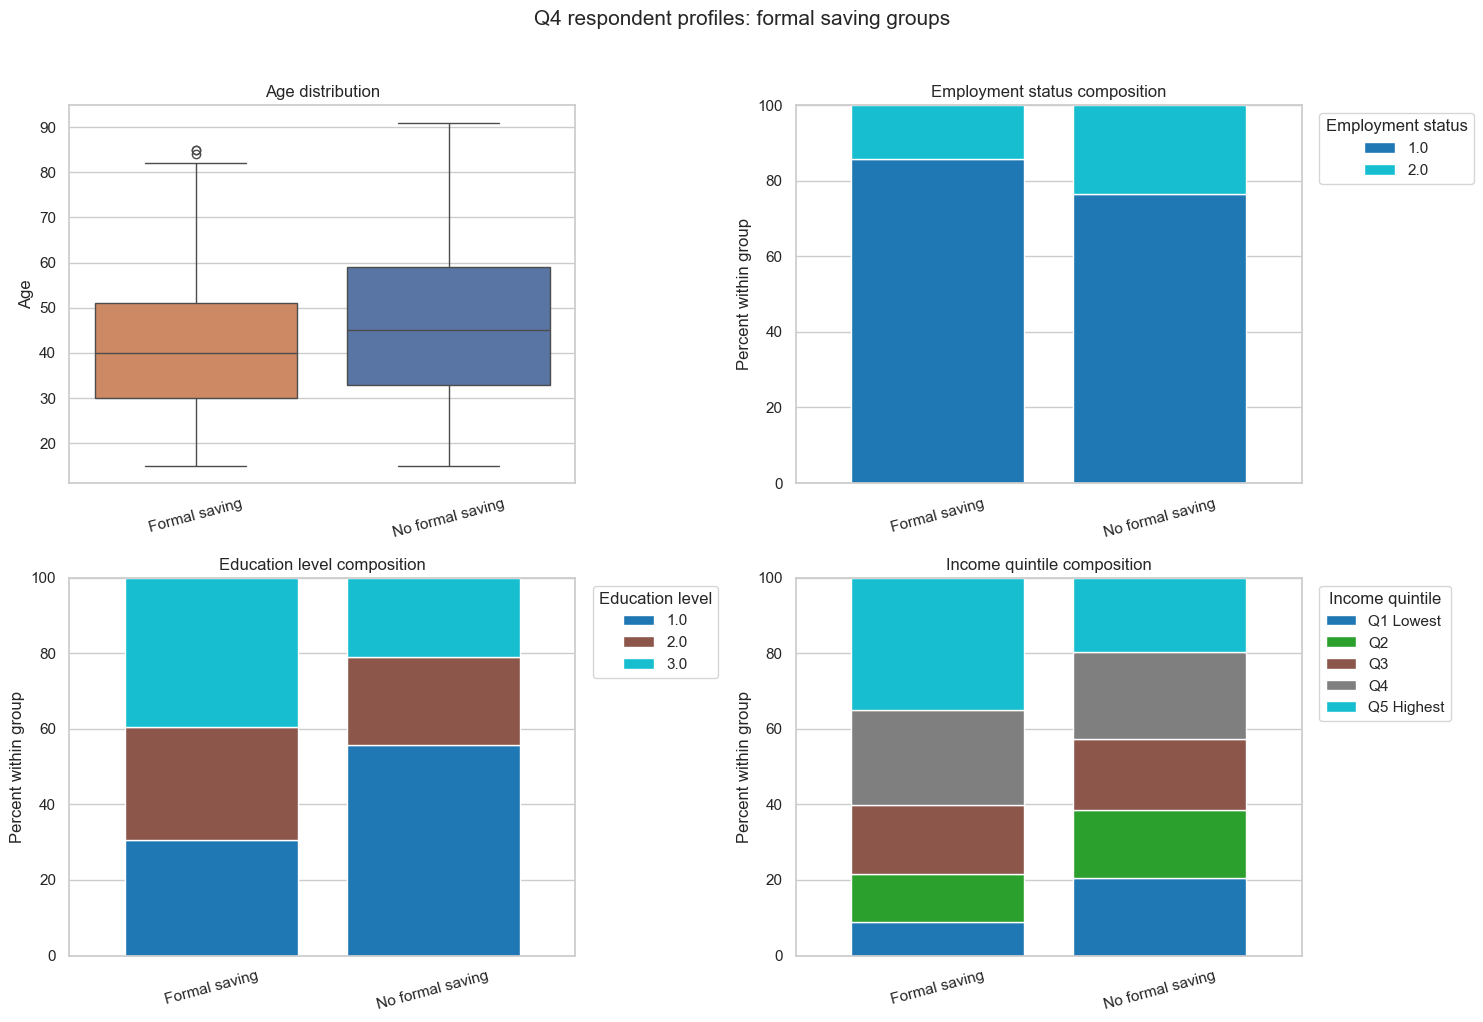

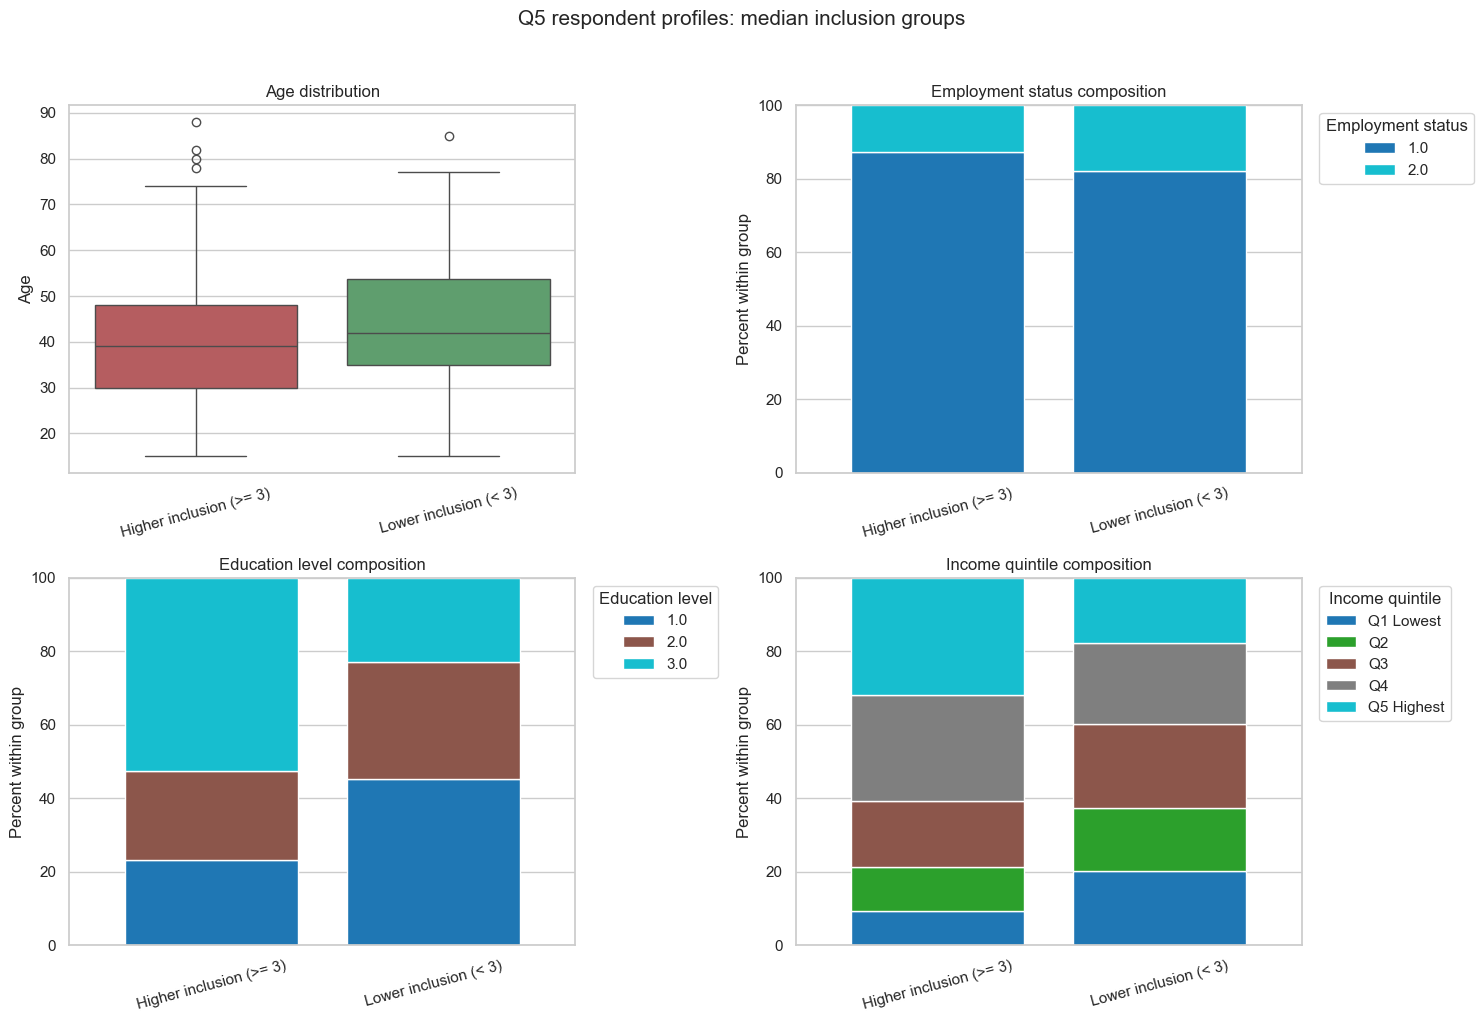

Q4 profile observations: 1686
Q4 group counts:
Saving group
Formal saving       986
No formal saving    700
Name: count, dtype: int64

Q5 profile observations: 961
Q5 inclusion index distribution:
inclusion_breadth
2.0    174
3.0    489
4.0    298
Name: count, dtype: int64
Q5 group counts:
Inclusion group
Higher inclusion (>= 3)    787
Lower inclusion (< 3)      174
Name: count, dtype: int64


In [ ]:
# descriptive groups from the same complete cases used in each model.
q4_profile = analysis.loc[q4_data.index].copy()
q4_profile["Saving group"] = q4_profile["formal_saving"].map(
    {0.0: "No formal saving", 1.0: "Formal saving"}
)
q5_profile = analysis.loc[q5_data.index].copy()
q5_median = q5_profile["inclusion_breadth"].median()
q5_profile["Inclusion group"] = np.where(
    q5_profile["inclusion_breadth"] < q5_median,
    f"Lower inclusion (< {q5_median:.0f})",
    f"Higher inclusion (>= {q5_median:.0f})",
)

profile_colors = {
    "No formal saving": "#4c72b0",
    "Formal saving": "#dd8452",
    f"Lower inclusion (< {q5_median:.0f})": "#55a868",
    f"Higher inclusion (>= {q5_median:.0f})": "#c44e52",
}


def plot_profile(data, group_column, title):
    figure, axes = plt.subplots(2, 2, figsize=(15, 10))
    figure.suptitle(title, fontsize=15, y=1.02)

    sns.boxplot(
        data=data,
        x=group_column,
        y="age",
        hue=group_column,
        palette=profile_colors,
        legend=False,
        ax=axes[0, 0],
    )
    axes[0, 0].set_title("Age distribution")
    axes[0, 0].set_xlabel("")
    axes[0, 0].set_ylabel("Age")
    axes[0, 0].tick_params(axis="x", rotation=15)

    categorical_specs = [
        ("employment_status", "Employment status", axes[0, 1]),
        ("education_level", "Education level", axes[1, 0]),
        ("income_quintile", "Income quintile", axes[1, 1]),
    ]
    for variable, label, axis in categorical_specs:
        proportions = pd.crosstab(
            data[group_column], data[variable], normalize="index"
        ).mul(100)
        proportions.plot(
            kind="bar",
            stacked=True,
            ax=axis,
            colormap="tab10",
            width=0.78,
        )
        axis.set_title(f"{label} composition")
        axis.set_xlabel("")
        axis.set_ylabel("Percent within group")
        axis.set_ylim(0, 100)
        axis.tick_params(axis="x", rotation=15)
        axis.legend(title=label, bbox_to_anchor=(1.02, 1), loc="upper left")

    figure.tight_layout()
    plt.show()


plot_profile(
    q4_profile,
    "Saving group",
    "Q4 respondent profiles: formal saving groups",
)
plot_profile(
    q5_profile,
    "Inclusion group",
    "Q5 respondent profiles: median inclusion groups",
)

print("Q4 profile observations:", len(q4_profile))
print("Q4 group counts:")
print(q4_profile["Saving group"].value_counts())
print("\nQ5 profile observations:", len(q5_profile))
print("Q5 inclusion index distribution:")
print(q5_profile["inclusion_breadth"].value_counts().sort_index())
print("Q5 group counts:")
print(q5_profile["Inclusion group"].value_counts())

In [28]:
# Numerical summaries used to support the written interpretation.
def profile_summary(data, group_column):
    age_summary = data.groupby(group_column)["age"].agg(["count", "mean", "median", "std"]).round(1)
    employment_share = pd.crosstab(
        data[group_column], data["employment_status"], normalize="index"
    ).mul(100).round(1)
    education_share = pd.crosstab(
        data[group_column], data["education_level"], normalize="index"
    ).mul(100).round(1)
    income_share = pd.crosstab(
        data[group_column], data["income_quintile"], normalize="index"
    ).mul(100).round(1)
    return age_summary, employment_share, education_share, income_share

q4_profile_summaries = profile_summary(q4_profile, "Saving group")
q5_profile_summaries = profile_summary(q5_profile, "Inclusion group")

print("Q4 age summary")
display(q4_profile_summaries[0])
print("Q4 employment percentages")
display(q4_profile_summaries[1])
print("Q4 education percentages")
display(q4_profile_summaries[2])
print("Q4 income-quintile percentages")
display(q4_profile_summaries[3])

print("Q5 age summary")
display(q5_profile_summaries[0])
print("Q5 employment percentages")
display(q5_profile_summaries[1])
print("Q5 education percentages")
display(q5_profile_summaries[2])
print("Q5 income-quintile percentages")
display(q5_profile_summaries[3])

Q4 age summary


,count,mean,median,std
Saving group,,,,
Formal saving,986,41.1,40.0,14.6
No formal saving,700,46.1,45.0,16.6


Q4 employment percentages


employment_status,1.0,2.0
Saving group,,
Formal saving,85.7,14.3
No formal saving,76.6,23.4


Q4 education percentages


...

employment_status,1.0,2.0
Inclusion group,,
Higher inclusion (>= 3),87.4,12.6
Lower inclusion (< 3),82.2,17.8


Q5 education percentages


education_level,1.0,2.0,3.0
Inclusion group,,,
Higher inclusion (>= 3),23.3,24.2,52.5
Lower inclusion (< 3),45.4,31.6,23.0


Q5 income-quintile percentages


income_quintile,Q1 Lowest,Q2,Q3,Q4,Q5 Highest
Inclusion group,,,,,
Higher inclusion (>= 3),9.4,12.1,17.9,28.8,31.8
Lower inclusion (< 3),20.1,17.2,23.0,21.8,17.8


## Interpretation of respondent profiles

### What does "higher inclusion" mean?

In the Q5 visualization, **higher inclusion** means that a respondent has at least 3 of the 4 financial-inclusion components in the index:

1. Formal account ownership.
2. Financial-institution account ownership.
3. Mobile-money account ownership.
4. Account transaction activity.

The higher-inclusion group therefore has an inclusion score of 3 or 4. The lower-inclusion group has a score below 3. This split is used only to make the profiles easier to visualize. The Q5 regression uses the original inclusion score from 0 to 4 as a numeric predictor.

### Q4: Formal-saving group profile

The Q4 complete-case sample contains 1,686 respondents: 986 formal savers and 700 respondents who did not report formal saving.

- Formal savers are younger on average: mean age **41.1 years**, compared with **46.1 years** among non-formal savers.
- Formal savers are more concentrated in employment category 1 (**85.7%**) than non-formal savers (**76.6%**). Employment category 2 represents **14.3%** of formal savers and **23.4%** of non-formal savers.
- Formal savers are more concentrated in education category 3 (**39.4%**) than non-formal savers (**21.0%**). Non-formal savers are more concentrated in education category 1 (**55.7%**) than formal savers (**30.6%**).
- Formal saving has a clear income gradient: **34.9%** of formal savers are in the highest income quintile, compared with **19.6%** of non-formal savers. Only **8.9%** of formal savers are in the lowest quintile, compared with **20.6%** of non-formal savers.

These descriptive differences indicate that formal savers are not demographically identical to non-formal savers. The positive Q4 association may therefore partly reflect differences in age, education, employment, and income, which is why these variables are included as controls in the regression model.

### Q5: Financial-inclusion group profile

The Q5 complete-case sample contains 961 respondents: 787 in the higher-inclusion group and 174 in the lower-inclusion group. The inclusion scores observed in this complete-case sample are 2, 3, and 4; the median score is 3.

- Higher-inclusion respondents are younger on average: mean age **39.5 years**, compared with **43.4 years** among lower-inclusion respondents.
- Higher-inclusion respondents are slightly more concentrated in employment category 1 (**87.4%**) than lower-inclusion respondents (**82.2%**).
- Education differences are substantial: **52.5%** of the higher-inclusion group are in education category 3, compared with **23.0%** of the lower-inclusion group. The lower-inclusion group is more concentrated in education category 1 (**45.4%**) than the higher-inclusion group (**23.3%**).
- Higher inclusion is also associated descriptively with higher income: **31.8%** of the higher-inclusion group are in the highest income quintile, compared with **17.8%** of the lower-inclusion group. The lowest quintile represents **9.4%** of the higher-inclusion group and **20.1%** of the lower-inclusion group.

### Main insight

The visualizations suggest that formal saving and broader financial inclusion are more common among younger, more highly educated, and higher-income respondents. This supports adjusting for age, education, income, and employment in Q4 and Q5. However, these plots are descriptive and do not prove that inclusion causes greater resilience. The regression results estimate the association after adjustment, while unmeasured factors and the smaller Q5 complete-case sample may still influence the relationship.



### How the Q5 model answers the research question

### Research question

**Is greater financial inclusion associated with greater financial resilience in Thailand?**

### Statistical translation

- **Predictor:** `inclusion_breadth`, scored from 0 to 4. A one-unit increase means one additional inclusion component is present.
- **Outcome:** ordered `emergency_fund_access`, where 1 = very difficult, 2 = somewhat difficult, and 3 = no difficulty obtaining emergency funds within 30 days.
- **Model:** adjusted ordered logistic regression.
- **Controls:** age, education level, income quintile, employment status, and survey year.

The null hypothesis is $H_0: \beta_{inclusion}=0$, meaning that financial inclusion is not associated with the odds of being in a higher resilience category. The alternative hypothesis is $H_A: \beta_{inclusion}\ne0$.

### Result and decision

The inclusion coefficient has an odds ratio of **1.316**, with a 95% confidence interval of **[1.076, 1.610]** and p = **0.008**.

Because the confidence interval does not include 1 and p < 0.05, reject $H_0$. In this sample, each additional financial-inclusion component is associated with **31.6% higher odds** of being in a higher financial-resilience category, holding the control variables constant.



**Greater financial inclusion is statistically significantly associated with greater financial resilience in Thailand.** Respondents with more inclusion components tend to report easier access to emergency funds.

This conclusion is about an adjusted association, not proof of causation. The model should not be interpreted as showing that increasing inclusion will definitely cause resilience to increase. The Q5 estimate is based on 961 complete observations, and the analysis should ideally be supplemented by a formal proportional-odds check and survey-weighted standard errors if the survey design information is available.

### How to check the result

1. Confirm that the inclusion odds ratio is above 1.
2. Check whether the 95% confidence interval excludes 1.
3. Check whether the p-value is below 0.05.
4. Confirm that the resilience categories are correctly ordered.
5. Report the adjusted controls and complete-case sample size.
6. Describe the result as an association rather than a causal effect.

## Business report: financial resilience models

### Executive summary

This analysis asks whether access to formal financial services and saving is linked to a person's ability to handle an emergency within 30 days.

The statistical evidence indicates:

- **Q4:** Respondents who saved formally had higher financial resilience. Their odds of reporting an easier emergency-fund situation were about **1.99 times** the odds for respondents without formal saving, after adjustment for demographic and economic characteristics.
- **Change over time:** The formal-saving relationship did not change significantly between 2021 and 2024. The interaction p-value was **0.774**.
- **Q5:** Each additional financial-inclusion component was associated with **1.316 times the odds** of being in a higher resilience category. This is approximately **31.6% higher odds** per additional component, with p = **0.008**.

These results show statistically significant associations. They do not prove that formal saving or inclusion causes resilience to increase.

### What the code does

#### 1. Selects the correct resilience outcome

The code uses `emergency_fund_access` as the outcome because this variable directly measures difficulty obtaining emergency money within 30 days:

- 1 = very difficult
- 2 = somewhat difficult
- 3 = no difficulty
- 4 = don't know
- 5 = refused

Only categories 1, 2, and 3 are modeled. The unanswered, don't-know, and refused responses are excluded because they do not provide a valid ordered resilience level.

Because the categories have a meaningful order, the analysis uses **ordered logistic regression**. The model estimates the odds of being in a higher category, meaning easier access to emergency funds and greater measured resilience.

The variables `emergency_fund` and `emergency_fund_source` are not substituted for this outcome. They measure the source of emergency money and the length of household expense coverage, respectively.

#### 2. Defines the Q4 formal-saving measure

`formal_saving` equals 1 when the respondent reported saving at a bank or other formal financial institution and equals 0 when the respondent did not. Invalid, don't-know, and refused responses are treated as missing and excluded from the Q4 model.

Q4 estimates three effects:

- `formal_saving`: the formal-saving association in the reference year, 2021.
- `survey_year_2024`: the change from 2021 to 2024 among respondents without formal saving.
- `formal_saving_x_2024`: whether the formal-saving association itself changed between 2021 and 2024.

The interaction is the direct statistical test for the second part of Q4.

#### 3. Builds the Q5 financial-inclusion measure

The Q5 index counts four inclusion components, each scored 0 or 1:

1. Formal account ownership.
2. Financial-institution account ownership.
3. Mobile-money account ownership.
4. Account transaction activity.

The resulting `inclusion_breadth` score ranges from 0 to 4. A one-unit increase means that the respondent has one additional inclusion component.

The regression uses this score as a numeric measure. The visualization's lower-inclusion and higher-inclusion groups are only descriptive groupings and are not the main Q5 statistical test.

#### 4. Adjusts for other characteristics

The models control for:

- Age
- Education level
- Income quintile
- Employment status
- Survey year

This means the reported association between saving or inclusion and resilience compares respondents while statistically holding these characteristics constant. This is important because the descriptive plots show that formal savers and higher-inclusion respondents tend to differ in age, education, employment, and income.

#### 5. Creates comparable model inputs

The code converts categorical control variables into indicator variables using `pd.get_dummies()`. This allows the regression to compare each category with a reference category. It also creates a binary indicator for 2024, leaving 2021 as the reference year.

Rows with missing values in the outcome, predictor, or controls are removed using `dropna()`. Therefore, the final estimates are based on complete observations:

- Q4: **1,686 respondents**
- Q5: **961 respondents**

#### 6. Produces interpretable results

The model coefficient is converted into an odds ratio using:

$$
OR = e^{\beta}
$$

For the ordered outcome:

- OR > 1 means higher odds of being in a more resilient category.
- OR < 1 means lower odds of being in a more resilient category.
- OR = 1 means no estimated association.

The 95% confidence interval shows the range of plausible odds ratios. If the interval excludes 1 and the p-value is below 0.05, the association is statistically significant at the 5% level.

### Business interpretation

The findings suggest that financial inclusion and formal saving are markers of stronger emergency financial capacity in Thailand. Respondents connected to formal financial institutions and those with more forms of account access and usage are more likely to report that obtaining emergency funds would be easier.

From a business or policy perspective, this pattern supports examining products and programs that improve account ownership, mobile-money access, and meaningful account usage. However, the analysis cannot determine whether expanding these services will itself cause resilience to improve. People who save formally may already have higher incomes, more education, stable employment, or other advantages. The model controls for several of these factors, but unmeasured differences may remain.

### Reporting conclusion

**Q4:** Formal saving is positively and significantly associated with financial resilience. There is no statistical evidence that the strength of this association changed between 2021 and 2024.

**Q5:** Greater financial-inclusion breadth is positively and significantly associated with financial resilience. Each additional inclusion component corresponds to approximately 31.6% higher odds of being in a higher emergency-fund-access category, conditional on the controls.

The conclusions should be reported as **adjusted associations**, not causal effects. Survey weights and the complex survey design are not included in this current model, and the proportional-odds assumption should be checked before treating the estimates as final.